Automated Financial Audit & Risk Detection (100K Transactions)
Project Goal: Automating corporate financial control to identify VAT risks and procurement anomalies.

Stack: Python (Pandas, Numpy), Matplotlib, Data Synthesis, Financial Risk Modeling.

## Step 1: Data Synthesis & Engineering
Generating a synthetic dataset of 100,000 transactions to simulate real-world corporate ERP exports.

In [7]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Configuration for synthetic dataset
n_rows = 100000
categories = ['Marketing', 'Rent', 'IT Services', 'Payroll', 'Office Supplies', 'Legal', 'Logistics']
counterparties = [f'Partner_{i}' for i in range(1, 51)]

# Generating base data (lists instead of dict direct creation for flexibility)
dates = [datetime(2024, 1, 1) + timedelta(days=random.randint(0, 500)) for _ in range(n_rows)]
c_parties = [random.choice(counterparties) for _ in range(n_rows)]
cats = [random.choice(categories) for _ in range(n_rows)]
amounts = np.random.uniform(100, 50000, n_rows).round(2)
tax_rates = [random.choice([0, 10, 20]) for _ in range(n_rows)]

# Logic: Increase risk for IT and Legal (60% missing docs), keep others low (10%)
doc_status = []
for category in cats:
    if category in ['IT Services', 'Legal']:
        doc_status.append(random.choice([True, False, False, False])) # Higher risk
    else:
        doc_status.append(random.choice([True]*9 + [False])) # Standard 10% risk

data = {
    'Transaction_ID': range(1, n_rows + 1),
    'Date': dates,
    'Counterparty': c_parties,
    'Category': cats,
    'Amount': amounts,
    'Tax_Rate': tax_rates,
    'Document_Status': doc_status 
}

df = pd.DataFrame(data)

# Injecting artificial anomalies for audit testing
df.loc[(df['Amount'] > 45000) & (df['Category'] == 'Office Supplies'), 'Tax_Rate'] = 0

# Exporting to CSV
df.to_csv('financial_data.csv', index=False)
print(f"Dataset with {n_rows} rows generated successfully. Anomalies injected!")

Dataset with 100000 rows generated successfully. Anomalies injected!


## Step 2: Automated Audit Procedures
Scanning for missing primary documentation and tax compliance risks. Focus threshold: > 30,000 KZT.

In [8]:
import pandas as pd

# Loading the dataset
raw_data = pd.read_csv('financial_data.csv')

print("--- RUNNING FINANCIAL AUDIT SCRIPT ---")

# 1. Missing Documentation Risk
# High-priority: transactions > 30k KZT without supporting docs
missing_docs = raw_data[(raw_data['Document_Status'] == False) & (raw_data['Amount'] > 30000)]
total_risk_amount = missing_docs['Amount'].sum()

print(f"CRITICAL: Found {len(missing_docs)} high-value transactions missing docs.")
print(f"TOTAL EXPOSURE: {total_risk_amount:,.2f} KZT")

# 2. Procurement Outliers
# Detecting unusually high 'Office Supplies' expenses (> 40k KZT)
procurement_anomalies = raw_data[(raw_data['Category'] == 'Office Supplies') & (raw_data['Amount'] > 40000)]
print(f"ANOMALIES: Detected {len(procurement_anomalies)} suspicious 'Office Supplies' entries.")

# 3. Tax Compliance Check (VAT Discrepancies)
# Identifying records with 0% tax rate in high-value procurement
vat_discrepancies = raw_data[(raw_data['Category'] == 'Office Supplies') & 
                             (raw_data['Amount'] > 40000) & 
                             (raw_data['Tax_Rate'] == 0)]

print(f"TAX COMPLIANCE: Found {len(vat_discrepancies)} VAT calculation errors.")

# TODO: Export VAT discrepancies for Tax Dept review
# vat_discrepancies.to_csv('vat_discrepancies_report.csv')

--- RUNNING FINANCIAL AUDIT SCRIPT ---
CRITICAL: Found 11445 high-value transactions missing docs.
TOTAL EXPOSURE: 457,817,241.44 KZT
ANOMALIES: Detected 2895 suspicious 'Office Supplies' entries.
TAX COMPLIANCE: Found 1852 VAT calculation errors.


## Step 3: Visual Risk Profiling
Visualizing financial exposure by category to prioritize audit resources (Pareto-based approach).

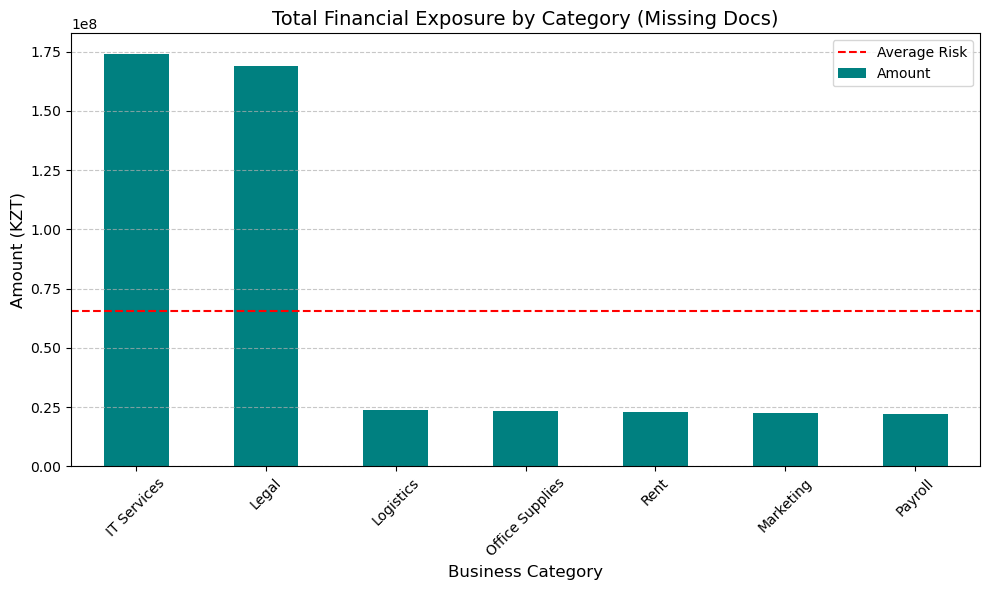

In [9]:
import matplotlib.pyplot as plt

# Grouping missing documentation risk by Category
risk_by_category = missing_docs.groupby('Category')['Amount'].sum().sort_values(ascending=False)

# Plotting the data
plt.figure(figsize=(10, 6))
risk_by_category.plot(kind='bar', color='teal')

# Professional styling
plt.title('Total Financial Exposure by Category (Missing Docs)', fontsize=14)
plt.xlabel('Business Category', fontsize=12)
plt.ylabel('Amount (KZT)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding a horizontal line for average risk level
plt.axhline(risk_by_category.mean(), color='red', linestyle='--', label='Average Risk')
plt.legend()

plt.tight_layout()
plt.show()

## Step 4: Actionable Insights Export
Exporting high-risk transactions into Excel for the operational audit team.

In [11]:
# Filtering data by the two riskiest categories
it_risk = missing_docs[missing_docs['Category'] == 'IT Services']
legal_risk = missing_docs[missing_docs['Category'] == 'Legal']

# Out to Excel
with pd.ExcelWriter('Priority_Audit_List.xlsx') as writer:
    it_risk.to_excel(writer, sheet_name='IT_Services_Issues', index=False)
    legal_risk.to_excel(writer, sheet_name='Legal_Issues', index=False)

print("File Priority_Audit_List.xlsx is ready.")

File Priority_Audit_List.xlsx is ready.
